**Purpose:**
* Create the Chapter 4 cluster map programmatically, using the final
Assigned_Cluster labels and fresh text embeddings (title+abstract).

**Inputs:**
* data/processed/final_reading_list.csv
columns include at least: paperId, title, abstract
* data/processed/thematic_classification_results_final.csv
columns: paperId, Title, AI_Cluster, Manual_Cluster, Assigned_Cluster

**Outputs:**
* artifacts/portfolio_with_embeddings.parquet
* figs/cluster_map_pca.png
* figs/similarity_graph.png  (optional)

# 1. Setup

In [1]:
from __future__ import annotations

import os
import pickle
from pathlib import Path
from typing import Dict, Iterable, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import networkx as nx

/Users/stahlma/.pyenv/versions/causal-rl-ev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
READING_LIST_CSV = Path("data/processed/final_reading_list_clean.csv")
CLASSIFICATION_CSV = Path("data/processed/thematic_classification_results_final.csv")

ARTIFACTS_DIR = Path("artifacts"); ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path("figs"); FIGS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDINGS_OUT = ARTIFACTS_DIR / "portfolio_with_embeddings.parquet"
CLUSTER_PLOT_OUT = FIGS_DIR / "cluster_map_pca.png"
GRAPH_PLOT_OUT = FIGS_DIR / "similarity_graph.png"

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
PCA_RANDOM_STATE = 42

# Graph options (only used if the optional graph section is enabled)
COSINE_THRESHOLD = 0.65
GRAPH_MAX_NODES = 500

# Final cluster names expected in Assigned_Cluster
FINAL_CLUSTERS = {
    "Economic Optimization",
    "Grid Stability & Services",
    "Causal Methods",
    "Explainability & Interpretability",
}

# Rename mapping: American -> British spelling
CLUSTER_RENAMES = {"Economic Optimization": "Economic Optimisation"}

# Update FINAL_CLUSTERS to use the new spelling
FINAL_CLUSTERS = {CLUSTER_RENAMES.get(c, c) for c in FINAL_CLUSTERS}

# If MERGE_MAP already exists (or after re-running cells), ensure it includes the rename
if "MERGE_MAP" in globals() and isinstance(MERGE_MAP, dict):
    MERGE_MAP.update(CLUSTER_RENAMES)
else:
    # create a minimal merge map so loaders that run afterwards will apply the rename
    MERGE_MAP = CLUSTER_RENAMES.copy()

# 2. Data Loading

In [3]:
MERGE_MAP = {
    "Causal Discovery & Modeling": "Causal Methods",
    "Counterfactual Policy Evaluation": "Causal Methods",
    "Remove": "REMOVE",
    # Include the British spelling conversion from earlier
    "Economic Optimization": "Economic Optimisation",
}

In [4]:
def _norm(s: str) -> str:
    """Normalizes cluster strings by stripping and normalizing spaces/case."""
    return " ".join(str(s).strip().split())

def load_reading_list(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Reading list CSV not found: {path}")
    df = pd.read_csv(path)
    required = {"paperId", "title", "abstract"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns in reading list: {missing}")
    df["paperId"] = df["paperId"].astype(str)
    df["title"] = df["title"].astype(str).fillna("")
    df["abstract"] = df["abstract"].astype(str).fillna("")
    return df

def load_assigned_clusters(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Classification CSV not found: {path}")
    m = pd.read_csv(path)
    needed = {"paperId", "Assigned_Cluster"}
    if not needed.issubset(set(m.columns)):
        raise KeyError(f"thematic_classification_results_final.csv must include {needed}")
    m["paperId"] = m["paperId"].astype(str)
    # Normalize label strings
    m["Assigned_Cluster"] = m["Assigned_Cluster"].astype(str).map(_norm)
    # Apply merge map (case/spacing normalized first)
    m["Assigned_Cluster"] = m["Assigned_Cluster"].replace(MERGE_MAP)
    return m[["paperId", "Assigned_Cluster"]]

reading_df = load_reading_list(READING_LIST_CSV)
map_df = load_assigned_clusters(CLASSIFICATION_CSV)

# Merge on paperId
df = reading_df.merge(map_df, on="paperId", how="inner")
if df.empty:
    raise ValueError("Merge produced zero rows. Check that paperId values match across both CSVs.")

# Drop any rows explicitly marked for removal
before = len(df)
df = df[df["Assigned_Cluster"] != "REMOVE"].copy()
removed = before - len(df)

# Validate cluster labels after merge & filtering
unknown = set(df["Assigned_Cluster"].unique()) - FINAL_CLUSTERS
if unknown:
    raise ValueError(
        f"Unexpected cluster labels after merge/filter: {unknown}\n"
        f"Expected one of: {sorted(FINAL_CLUSTERS)}"
    )

print(f"Loaded {len(df)} papers after filtering ({removed} removed).")
print(df["Assigned_Cluster"].value_counts())

Loaded 70 papers after filtering (0 removed).
Assigned_Cluster
Grid Stability & Services            26
Causal Methods                       19
Economic Optimisation                18
Explainability & Interpretability     7
Name: count, dtype: int64


# 3. Embeddings

In [11]:
df.head()

,paperId,title,year,overall_citations,in_corpus_citations,venue,pagerank,norm_overall,norm_in_corpus,norm_pagerank,...,abstract,score_crl_methods,score_ev_applications,score_explainability_trust,methodology,contribution,methodology_group,priority_score,Assigned_Cluster,embedding
0,59021ecd3fd15c59b8b774c87ae974c9fffe9fa5,Model-Free Real-Time EV Charging Scheduling Ba...,2019,393,39,IEEE Transactions on Smart Grid,0.015975,0.224957,1.000000,0.833090,...,Driven by the recent advances in electric vehi...,1,10,1,Algorithm Development,The paper proposes a model-free deep reinforce...,Algorithm / Model Development,0.794918,Economic Optimization,"[-0.08979135006666183, 0.061374418437480927, 0..."
1,648ea87fe7f99ca8ea5090cb1ba40242299ef4c4,Reinforcement learning for demand response: A ...,2019,604,31,Applied Energy,0.016781,0.345736,0.794872,0.875099,...,A need is identified to further explore reinfo...,3,9,1,Research Proposal,The paper identifies the need to explore reinf...,Other,0.729113,Economic Optimization,"[-0.07535338401794434, 0.03498223423957825, 0...."
2,7158277c0361f15a7c67621f5940c4208c9c46ce,Optimizing renewable energy systems through ar...,2024,104,0,Energy &amp; Environment,0.000000,NaN,NaN,NaN,...,The global transition toward sustainable energ...,2,4,8,Literature Review,This paper provides a comprehensive review of ...,Review / Survey,0.520000,Grid Stability & Services,"[-0.08455083519220352, 0.029123084619641304, 0..."
3,cd3c9cba90f778ada660a462d58573756c60fb27,Reinforcement Learning-Based Plug-in Electric ...,2017,157,24,IEEE Transactions on Vehicular Technology,0.009878,0.089868,0.615385,0.515149,...,This paper proposes a novel demand response me...,2,10,1,Algorithm Development,The paper proposes a novel demand response met...,Algorithm / Model Development,0.480211,Economic Optimization,"[-0.09798596054315567, 0.11678027361631393, 0...."
4,745a134eca192982e8e0c16d6f36cfe24f9bdd08,"Woulda, Coulda, Shoulda: Counterfactually-Guid...",2018,143,11,International Conference on Learning Represent...,0.018275,0.081855,0.282051,0.953021,...,Learning policies on data synthesized by model...,10,2,3,Algorithm Development,The paper proposes the Counterfactually-Guided...,Algorithm / Model Development,0.443303,Causal Methods,"[-0.11636104434728622, -0.032905831933021545, ..."


In [6]:
def build_text(row: pd.Series) -> str:
    """Constructs the text to embed from title+abstract."""
    title = str(row.get("title", "")).strip()
    abstract = str(row.get("abstract", "")).strip()
    return f"{title}. {abstract}" if abstract else title

def embed_texts(texts: Iterable[str], model_name: str) -> np.ndarray:
    """Computes normalized sentence embeddings; uses tqdm if available."""
    model = SentenceTransformer(model_name)
    texts = list(texts)
    if tqdm:
        return model.encode(texts, batch_size=64, show_progress_bar=True,
                            convert_to_numpy=True, normalize_embeddings=True)
    return model.encode(texts, batch_size=64, convert_to_numpy=True, normalize_embeddings=True)

def ensure_embeddings(_df: pd.DataFrame, cache_path: Path) -> pd.DataFrame:
    """
    Loads cached embeddings if consistent with current rows; otherwise recomputes.
    Tries both parquet and pickle formats.
    """
    # Try parquet first
    if cache_path.exists():
        try:
            cached = pd.read_parquet(cache_path)
            ok = (
                len(cached) == len(_df)
                and "embedding" in cached.columns
                and cached["paperId"].tolist() == _df["paperId"].tolist()
            )
            if ok:
                print(f"Loaded cached embeddings from parquet: {cache_path}")
                return cached
            else:
                print("Parquet cache exists but does not match current rows/order; checking pickle...")
        except Exception as e:
            print(f"Parquet cache exists but could not be read ({e}); checking pickle...")
    
    # Try pickle fallback
    pickle_path = cache_path.with_suffix('.pkl')
    if pickle_path.exists():
        try:
            cached = pd.read_pickle(pickle_path)
            ok = (
                len(cached) == len(_df)
                and "embedding" in cached.columns
                and cached["paperId"].tolist() == _df["paperId"].tolist()
            )
            if ok:
                print(f"Loaded cached embeddings from pickle: {pickle_path}")
                return cached
            else:
                print("Pickle cache exists but does not match current rows/order; recomputing...")
        except Exception as e:
            print(f"Pickle cache exists but could not be read ({e}); recomputing embeddings...")

    # Recompute embeddings
    print("Computing fresh embeddings...")
    texts = _df.apply(build_text, axis=1)
    emb = embed_texts(texts, EMBEDDING_MODEL_NAME)
    out = _df.copy()
    
    # Convert embeddings to lists of floats for compatibility
    out["embedding"] = [emb_row.astype(float).tolist() for emb_row in emb]
    
    # Try to save as parquet first, fallback to pickle
    try:
        out.to_parquet(cache_path, index=False)
        print(f"Saved embeddings cache as parquet: {cache_path}")
    except Exception as e:
        print(f"Failed to save parquet ({e}), saving as pickle instead...")
        pickle_path = cache_path.with_suffix('.pkl')
        out.to_pickle(pickle_path)
        print(f"Saved embeddings cache as pickle: {pickle_path}")
        
    return out

df = ensure_embeddings(df, EMBEDDINGS_OUT)

Loaded cached embeddings from pickle: artifacts/portfolio_with_embeddings.pkl


# 4. PCA projection and Scatter

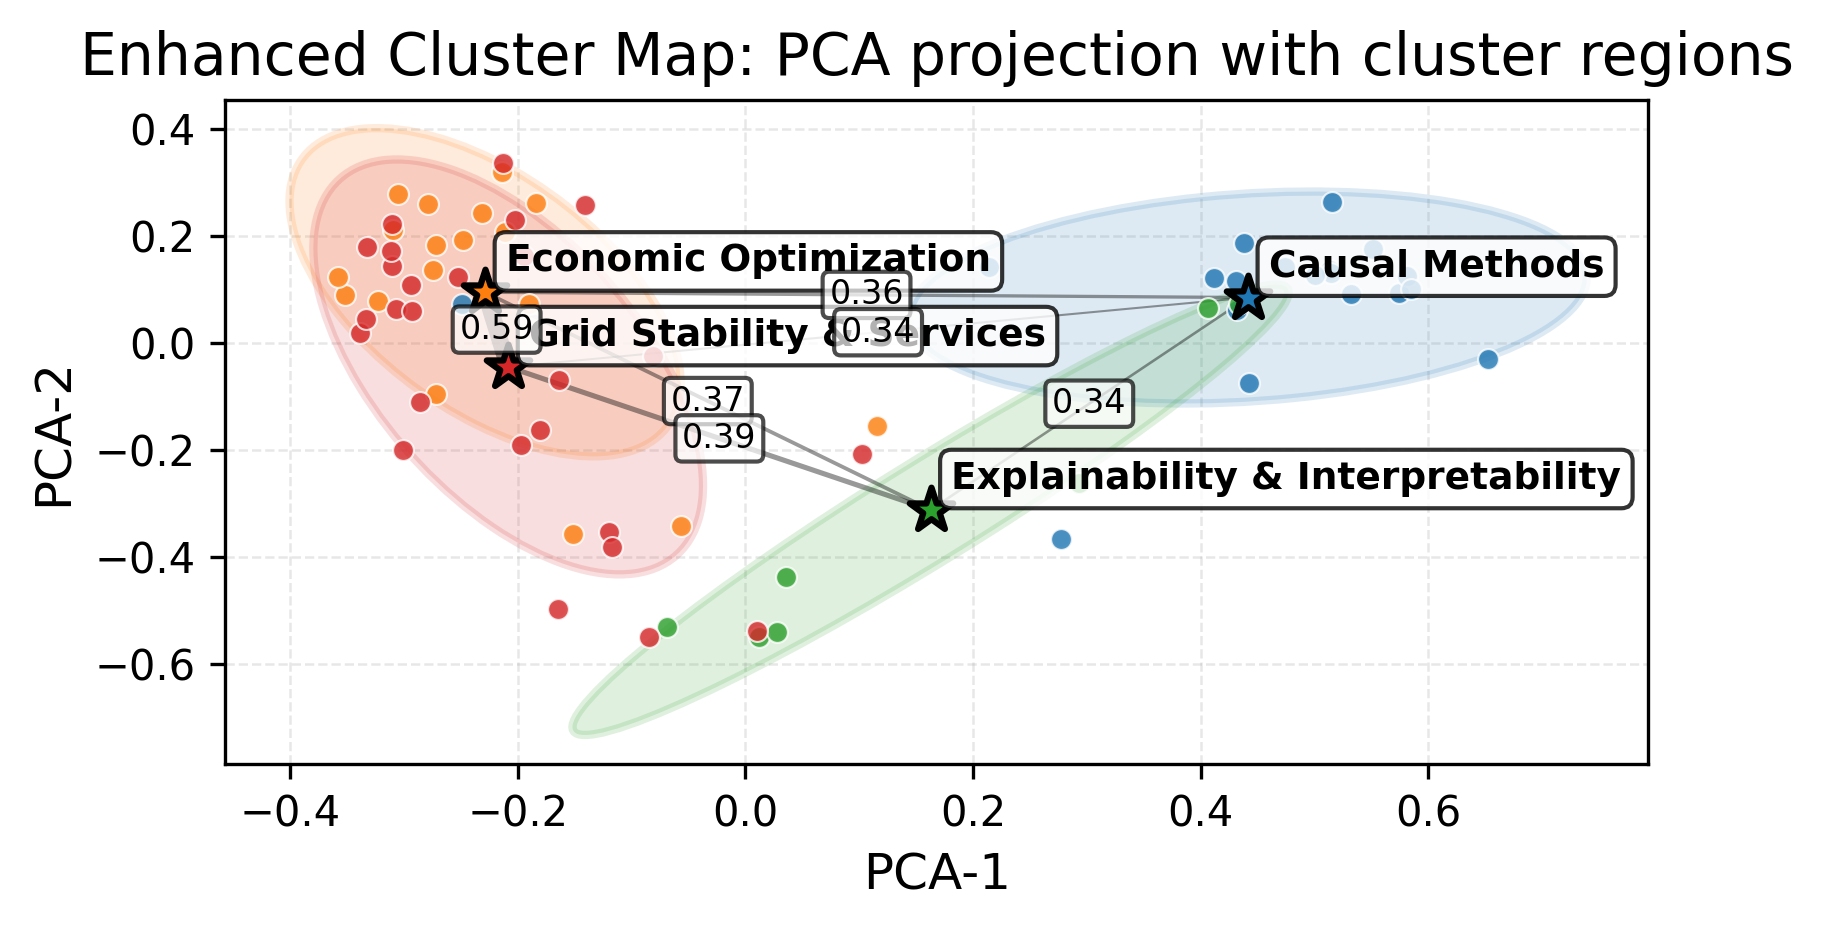

Saved enhanced cluster map: figs/cluster_map_enhanced.png


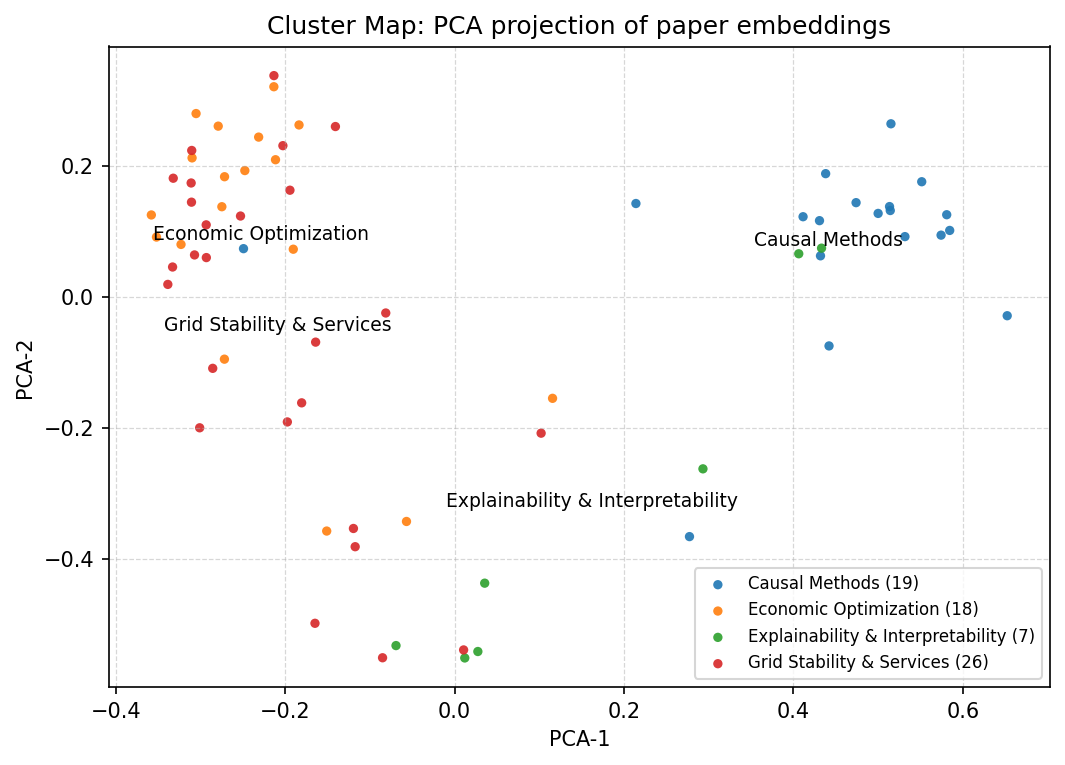

Saved: figs/cluster_map_pca.png


In [7]:
def pca_project(embeddings: np.ndarray, n_components: int = 2, random_state: int = PCA_RANDOM_STATE) -> np.ndarray:
    """Projects embeddings to 2D via PCA (deterministic given random_state)."""
    pca = PCA(n_components=n_components, random_state=random_state)
    return pca.fit_transform(embeddings)

def stack_embeddings(_df: pd.DataFrame) -> np.ndarray:
    """Stacks embeddings (list-of-floats) into a 2D numpy array with sanity checks."""
    if "embedding" not in _df.columns:
        raise KeyError("Column 'embedding' missing; ensure embeddings were computed.")
    emb = np.vstack(_df["embedding"].values)
    if not np.isfinite(emb).all():
        raise ValueError("Embeddings contain non-finite values.")
    return emb

def compute_cluster_centroids(df_reset: pd.DataFrame, coords_2d: np.ndarray) -> dict:
    """Compute cluster centroids in PCA space."""
    centroids = {}
    for cluster, sub in df_reset.groupby("Assigned_Cluster"):
        idx = sub.index.values
        centroid = np.mean(coords_2d[idx], axis=0)
        centroids[cluster] = centroid
    return centroids

def compute_covariance_ellipse(points: np.ndarray, confidence: float = 0.95) -> tuple:
    """Compute covariance ellipse parameters for a set of 2D points."""
    from matplotlib.patches import Ellipse
    import scipy.stats as stats
    
    if len(points) < 2:
        return None, None, None
    
    # Compute covariance matrix
    cov = np.cov(points.T)
    
    # Eigenvalues and eigenvectors
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    
    # Sort by eigenvalue
    order = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[order]
    eigenvecs = eigenvecs[:, order]
    
    # Compute ellipse parameters
    theta = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    
    # Chi-square value for confidence interval
    chi2_val = stats.chi2.ppf(confidence, df=2)
    width = 2 * np.sqrt(chi2_val * eigenvals[0])
    height = 2 * np.sqrt(chi2_val * eigenvals[1])
    
    return width, height, theta

def compute_inter_cluster_similarity(df_reset: pd.DataFrame, embeddings: np.ndarray) -> dict:
    """Compute average cosine similarity between clusters."""
    cluster_similarities = {}
    clusters = df_reset["Assigned_Cluster"].unique()
    
    for i, cluster1 in enumerate(clusters):
        for j, cluster2 in enumerate(clusters):
            if i < j:  # Only compute upper triangle
                # Get embeddings for each cluster
                idx1 = df_reset[df_reset["Assigned_Cluster"] == cluster1].index.values
                idx2 = df_reset[df_reset["Assigned_Cluster"] == cluster2].index.values
                
                emb1 = embeddings[idx1]
                emb2 = embeddings[idx2]
                
                # Compute all pairwise similarities and take average
                sims = cosine_similarity(emb1, emb2)
                avg_sim = np.mean(sims)
                
                cluster_similarities[(cluster1, cluster2)] = avg_sim
    
    return cluster_similarities

def plot_enhanced_cluster_scatter(_df: pd.DataFrame, coords_2d: np.ndarray, embeddings: np.ndarray, outpath: Path) -> None:
    """Enhanced cluster plot with ellipses, centroids, and inter-cluster edges."""
    from matplotlib.patches import Ellipse
    
    # Reset index to ensure consecutive indexing
    df_reset = _df.reset_index(drop=True)
    
    x, y = coords_2d[:, 0], coords_2d[:, 1]
    fig, ax = plt.subplots(figsize=(5.75, 3.2), dpi=300)
    ax.set_title("Enhanced Cluster Map: PCA projection with cluster regions", fontsize=14)
    ax.set_xlabel("PCA-1", fontsize=12)
    ax.set_ylabel("PCA-2", fontsize=12)

    # Get color palette
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    cluster_colors = {}
    centroids = compute_cluster_centroids(df_reset, coords_2d)
    
    # 1. Plot all papers as light points first (background)
    ax.scatter(x, y, s=15, c='lightgray', alpha=0.3, edgecolors="none", zorder=1)
    
    # 2. Plot cluster-specific points and covariance ellipses
    for i, (cluster, sub) in enumerate(df_reset.groupby("Assigned_Cluster")):
        color = colors[i % len(colors)]
        cluster_colors[cluster] = color
        idx = sub.index.values
        
        # Plot cluster points
        ax.scatter(x[idx], y[idx], s=25, c=color, label=f"{cluster} ({len(sub)})", 
                  alpha=0.8, edgecolors="white", linewidth=0.5, zorder=3)
        
        # Compute and plot covariance ellipse
        cluster_points = coords_2d[idx]
        if len(cluster_points) >= 3:  # Need at least 3 points for meaningful ellipse
            width, height, theta = compute_covariance_ellipse(cluster_points, confidence=0.68)
            if width is not None:
                centroid = centroids[cluster]
                ellipse = Ellipse(centroid, width, height, angle=theta, 
                                facecolor=color, alpha=0.15, edgecolor=color, 
                                linewidth=2, zorder=2)
                ax.add_patch(ellipse)
    
    # 3. Plot centroids
    for cluster, centroid in centroids.items():
        color = cluster_colors[cluster]
        ax.scatter(centroid[0], centroid[1], s=120, c=color, marker='*', 
                  edgecolors='black', linewidth=1.5, zorder=4)
        # Add cluster name near centroid
        ax.annotate(cluster, (centroid[0], centroid[1]), xytext=(5, 5), 
                   textcoords='offset points', fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                   zorder=5)
    
    # 4. Plot edges between centroids with width proportional to similarity
    inter_cluster_sims = compute_inter_cluster_similarity(df_reset, embeddings)
    
    # Normalize similarities to line widths (0.5 to 4.0)
    if inter_cluster_sims:
        sim_values = list(inter_cluster_sims.values())
        min_sim, max_sim = min(sim_values), max(sim_values)
        
        for (cluster1, cluster2), similarity in inter_cluster_sims.items():
            if similarity > 0.1:  # Only show edges with meaningful similarity
                # Normalize similarity to line width
                if max_sim > min_sim:
                    line_width = 0.5 + 3.5 * (similarity - min_sim) / (max_sim - min_sim)
                else:
                    line_width = 2.0
                
                cent1 = centroids[cluster1]
                cent2 = centroids[cluster2]
                
                ax.plot([cent1[0], cent2[0]], [cent1[1], cent2[1]], 
                       color='black', alpha=0.4, linewidth=line_width, zorder=2)
                
                # Add similarity label at midpoint
                mid_x = (cent1[0] + cent2[0]) / 2
                mid_y = (cent1[1] + cent2[1]) / 2
                ax.text(mid_x, mid_y, f'{similarity:.2f}', fontsize=8, 
                       ha='center', va='center', 
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),
                       zorder=5)

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.3)
    fig.tight_layout()
    fig.savefig(outpath, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved enhanced cluster map: {outpath}")

def plot_cluster_scatter(_df: pd.DataFrame, coords_2d: np.ndarray, outpath: Path) -> None:
    """Simple cluster plot (original version)."""
    # Reset index to ensure consecutive indexing for coordinates
    df_reset = _df.reset_index(drop=True)
    
    x, y = coords_2d[:, 0], coords_2d[:, 1]
    fig, ax = plt.subplots(figsize=(7.2, 5.2), dpi=150)
    ax.set_title("Cluster Map: PCA projection of paper embeddings")
    ax.set_xlabel("PCA-1")
    ax.set_ylabel("PCA-2")

    # Plots each cluster with default color cycle
    for cl, sub in df_reset.groupby("Assigned_Cluster"):
        idx = sub.index.values  # Now these will be consecutive
        ax.scatter(x[idx], y[idx], s=20, label=f"{cl} ({len(sub)})", alpha=0.9, edgecolors="none")

    # Adds centroid labels for readability
    for cl, sub in df_reset.groupby("Assigned_Cluster"):
        idx = sub.index.values
        cx, cy = float(np.mean(x[idx])), float(np.mean(y[idx]))
        ax.text(cx, cy, cl, fontsize=9, ha="center", va="center")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.legend(fontsize=8, loc="best", frameon=True)
    fig.tight_layout()
    fig.savefig(outpath, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outpath}")

# Generate both versions
emb = stack_embeddings(df)
coords = pca_project(emb, n_components=2, random_state=PCA_RANDOM_STATE)

# Enhanced version with all requested features
enhanced_plot_path = FIGS_DIR / "cluster_map_enhanced.png"
plot_enhanced_cluster_scatter(df, coords, emb, enhanced_plot_path)

# Original simple version
plot_cluster_scatter(df, coords, CLUSTER_PLOT_OUT)

# 5. (Optional) Cosine Threshold Similarity Graph

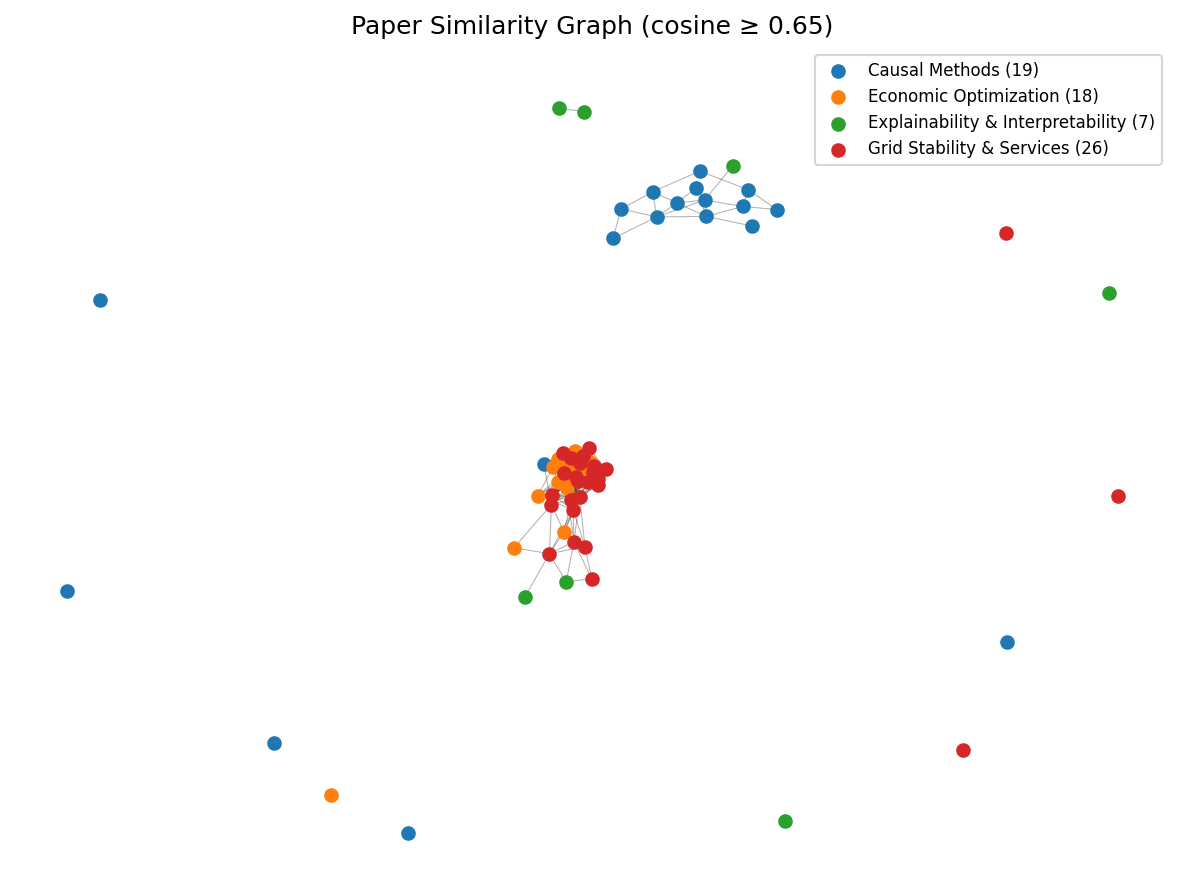

Saved: figs/similarity_graph.png


In [8]:
def build_similarity_graph(embeddings: np.ndarray,
                           ids: Iterable[str],
                           labels: Iterable[str],
                           cosine_threshold: float,
                           max_nodes: int):
    """Builds a thresholded cosine similarity graph (requires networkx)."""
    if nx is None:
        raise ImportError("Install networkx to build the similarity graph: pip install networkx")
    ids = list(ids)
    labels = list(labels)
    n = min(len(ids), max_nodes)
    ids = ids[:n]
    labels = labels[:n]
    emb = embeddings[:n]
    sims = cosine_similarity(emb)

    G = nx.Graph()
    for i in range(n):
        G.add_node(ids[i], label=labels[i])
    for i in range(n):
        for j in range(i + 1, n):
            if sims[i, j] >= cosine_threshold:
                G.add_edge(ids[i], ids[j], weight=float(sims[i, j]))
    return G

def plot_similarity_graph(G, outpath: Path) -> None:
    """Plots a spring layout graph with nodes colored by Assigned_Cluster."""
    labels = nx.get_node_attributes(G, "label")
    uniq = sorted(set(labels.values()))
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    cmap: Dict[str, str] = {lab: color_cycle[i % len(color_cycle)] for i, lab in enumerate(uniq)}

    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6), dpi=150)
    for lab in uniq:
        nodes = [n for n, l in labels.items() if l == lab]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_size=36, node_color=cmap[lab], label=f"{lab} ({len(nodes)})")
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3)

    plt.title(f"Paper Similarity Graph (cosine ≥ {COSINE_THRESHOLD})")
    plt.axis("off")
    plt.legend(fontsize=8, frameon=True, loc="best")
    plt.tight_layout()
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outpath}")

# Reset the DataFrame index before building the graph to ensure consecutive indexing
df_reset = df.reset_index(drop=True)

G = build_similarity_graph(
    embeddings=emb,
    ids=df_reset["paperId"].astype(str).tolist(),
    labels=df_reset["Assigned_Cluster"].astype(str).tolist(),
    cosine_threshold=COSINE_THRESHOLD,
    max_nodes=GRAPH_MAX_NODES,
)
plot_similarity_graph(G, GRAPH_PLOT_OUT)

# 6. Visuals for Paper

In [9]:
# --- stable cluster order + colors (uses matplotlib default cycle) ---
ORDERED_CLUSTERS = [
    "Causal Methods",
    "Economic Optimisation",  # British spelling
    "Explainability & Interpretability",
    "Grid Stability & Services",
]
COLOR_CYCLE = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
COLOR_MAP = {c: COLOR_CYCLE[i % len(COLOR_CYCLE)] for i, c in enumerate(ORDERED_CLUSTERS)}

def centroid_stats(df_reset: pd.DataFrame, coords_2d: np.ndarray):
    """Returns {cluster: {'mu': centroid(2,), 'cov': 2x2, 'idx': idx, 'n': count}}."""
    stats = {}
    for cl in ORDERED_CLUSTERS:
        sub = df_reset[df_reset["Assigned_Cluster"] == cl]
        idx = sub.index.values
        xy = coords_2d[idx, :]
        mu = xy.mean(axis=0)
        cov = np.cov(xy.T) if len(xy) >= 3 else np.eye(2) * 1e-3
        stats[cl] = {"mu": mu, "cov": cov, "idx": idx, "n": len(sub)}
    return stats

def plot_cov_ellipse(ax, mean, cov, n_std=1.6, color="k", alpha=0.12, lw=1.0):
    """Plots a covariance ellipse (no SciPy)."""
    from matplotlib.patches import Ellipse
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta,
                  edgecolor=color, facecolor=color, linewidth=lw, alpha=alpha)
    ax.add_patch(ell)

def intercluster_mean_cosine(df_reset: pd.DataFrame, embeddings: np.ndarray):
    """Mean cosine similarity between clusters: {(cli,clj): mean} (upper triangle)."""
    sims = cosine_similarity(embeddings)
    labels = df_reset["Assigned_Cluster"].values
    out = {}
    for i, cli in enumerate(ORDERED_CLUSTERS):
        for j, clj in enumerate(ORDERED_CLUSTERS):
            if j <= i: 
                continue
            idx_i = np.where(labels == cli)[0]
            idx_j = np.where(labels == clj)[0]
            if len(idx_i) == 0 or len(idx_j) == 0:
                continue
            out[(cli, clj)] = float(sims[np.ix_(idx_i, idx_j)].mean())
    return out

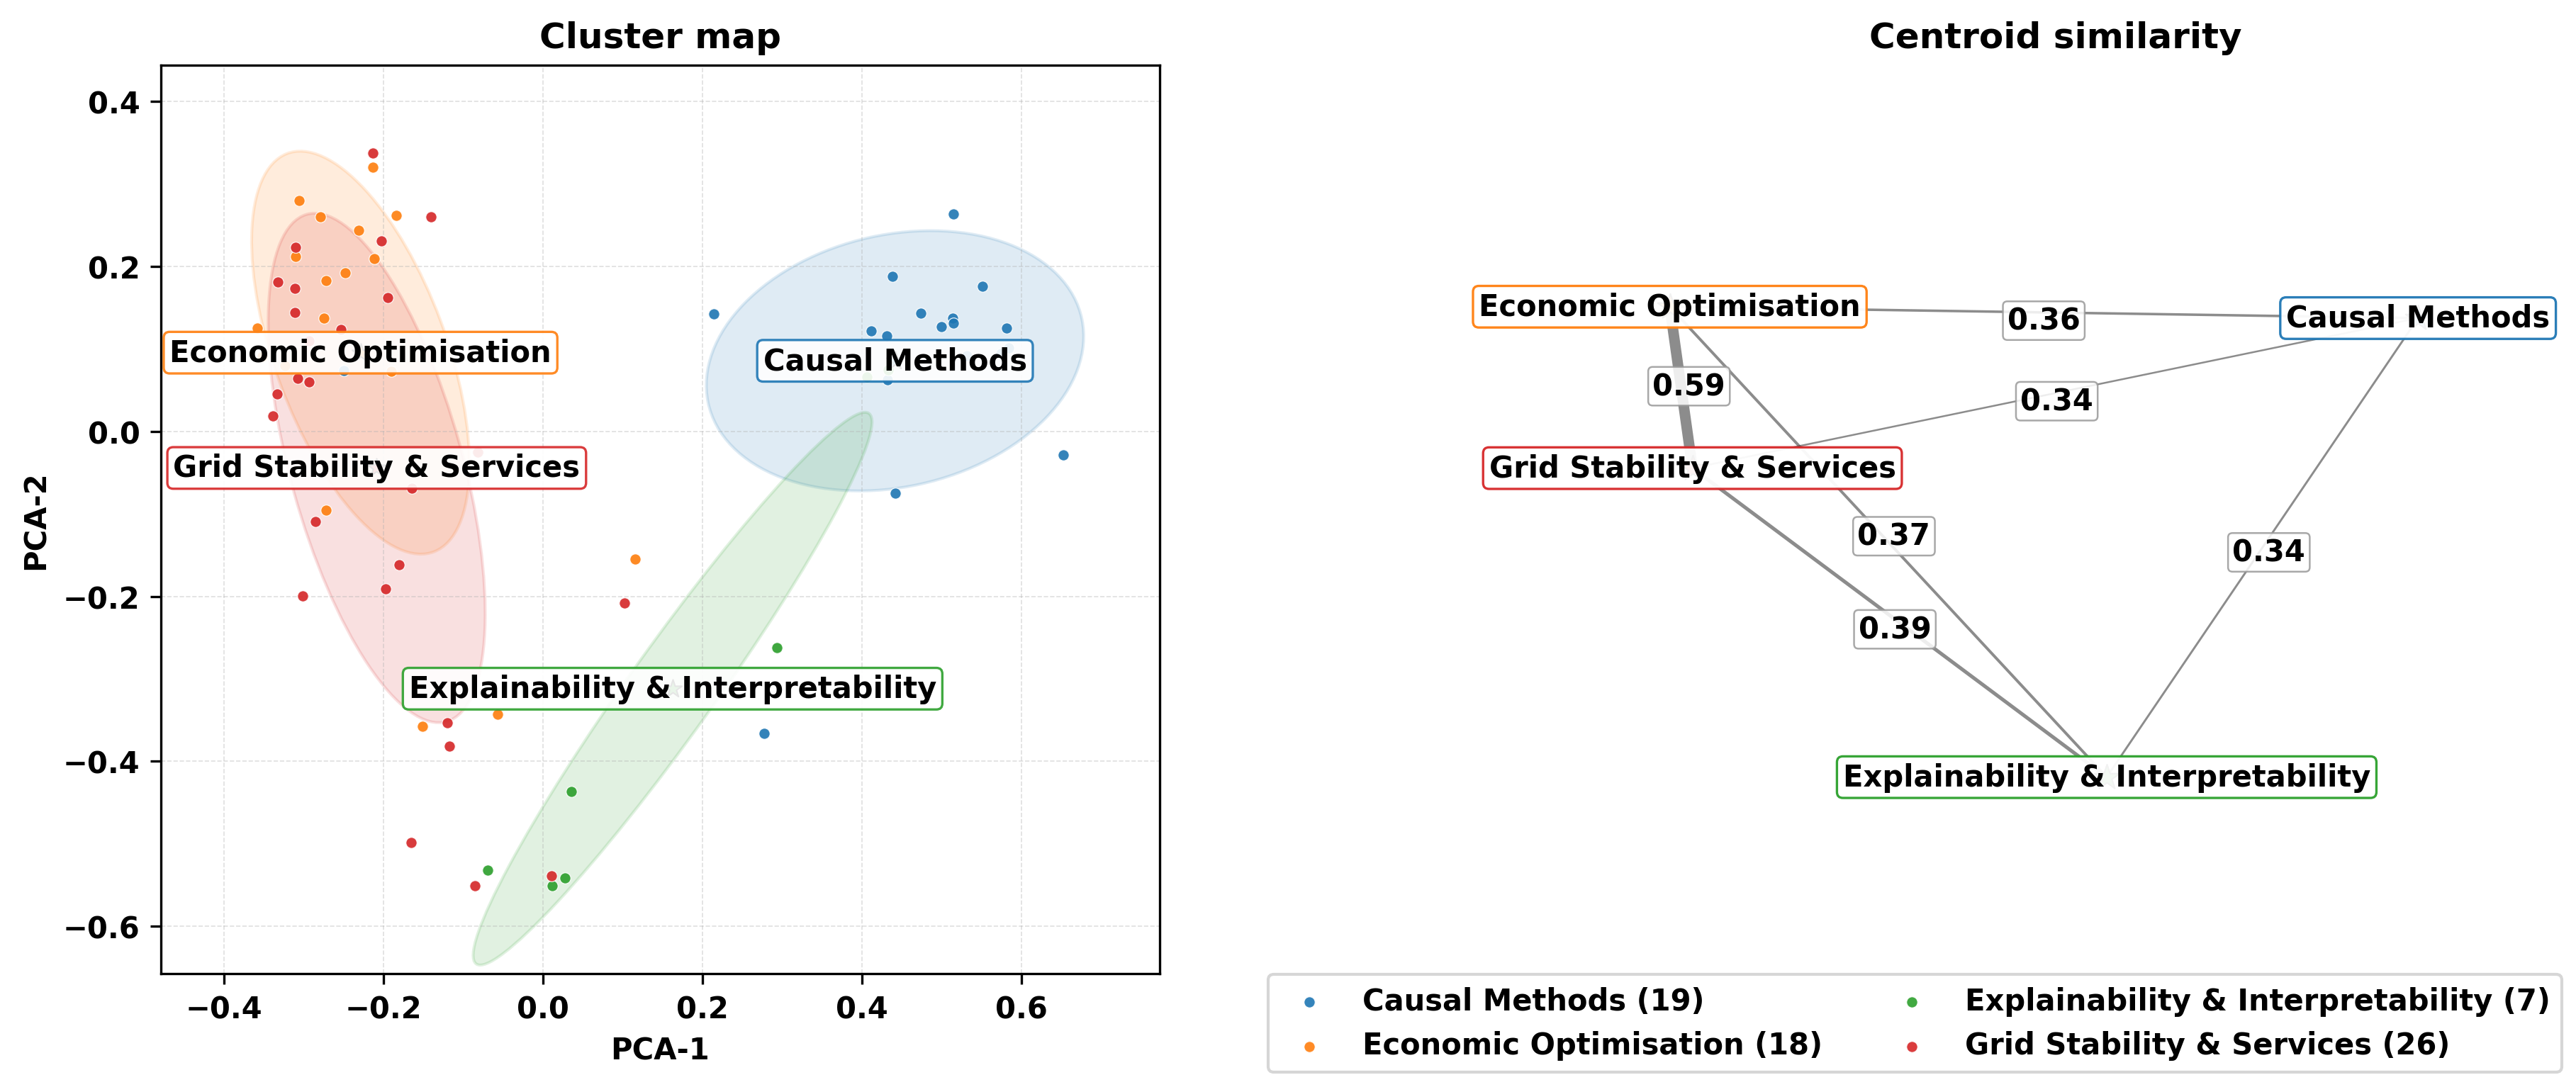

Saved: figs/cluster_map_dual_panel.png


In [14]:
def plot_dual_panel_cluster_and_centroid_graph(
    df: pd.DataFrame,
    coords_2d: np.ndarray,
    embeddings: np.ndarray,
    outpath: Path,
    title_left="Cluster map",
    title_right="Centroid similarity",
    *,
    font_axes=10,         # increased font size for better readability
    font_title=12,        # increased title font size
    legend_ncols=2,       # legend layout below both plots
    pad_frac=0.12,        # extra padding to avoid label/ellipse clipping
    spread_right=1.4     # >1.0 pushes right-panel centroids apart a bit
):
    """
    Left: cluster map with ellipses and centroids.
    Right: centroid-only similarity graph.
    Saves a side-by-side figure sized for ~quarter-page height.

    Security/robustness:
    - Does not execute external code or load remote resources.
    - Validates empty inter-cluster similarities.
    """
    # --- prep
    df_reset = df.reset_index(drop=True)
    stats = centroid_stats(df_reset, coords_2d)
    x, y = coords_2d[:, 0], coords_2d[:, 1]

    # --- figure: increased height for better readability in Word documents ---
    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=(12, 5), dpi=300,  # increased from (10.5, 3.2) to (12, 5)
        gridspec_kw={"wspace": 0.25},
        constrained_layout=True
    )

    # ---------------- Left panel ----------------
    axL.set_title(title_left, fontsize=font_title, fontweight='bold')
    axL.set_xlabel("PCA-1", fontsize=font_axes, fontweight='bold')
    axL.set_ylabel("PCA-2", fontsize=font_axes, fontweight='bold')
    axL.tick_params(labelsize=font_axes)
    # Make tick labels bold
    for label in axL.get_xticklabels() + axL.get_yticklabels():
        label.set_fontweight('bold')

    # light background scatter
    axL.scatter(x, y, s=10, c="0.88", alpha=0.5, edgecolors="none", zorder=1)

    handles = []
    labels = []

    # cluster points + ellipses + centroids
    for cl in ORDERED_CLUSTERS:
        s = stats[cl]
        idx = s["idx"]
        sc = axL.scatter(
            x[idx], y[idx], s=14, color=COLOR_MAP[cl], alpha=0.9,
            edgecolors="white", linewidth=0.3, zorder=3
        )
        # collect for figure-level legend
        handles.append(sc)
        labels.append(f"{cl} ({s['n']})")

        plot_cov_ellipse(axL, s["mu"], s["cov"],
                         n_std=1.2, color=COLOR_MAP[cl], alpha=0.14, lw=1.0)

        axL.scatter([s["mu"][0]], [s["mu"][1]], s=40, marker="*",
                    color=COLOR_MAP[cl], edgecolors="black", linewidths=0.5, zorder=4)

        # label with cluster color as border; clip_off so it never vanishes at edges
        axL.text(s["mu"][0], s["mu"][1], cl, fontsize=font_axes, ha="center", va="center",
                 fontweight='bold',  # make cluster labels bold
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                           edgecolor=COLOR_MAP[cl], linewidth=0.8, alpha=0.9),
                 zorder=5, clip_on=False)

    axL.grid(True, linestyle="--", linewidth=0.4, alpha=0.4)

    # ---------------- Right panel ----------------
    axR.set_title(title_right, fontsize=font_title, fontweight='bold')
    axR.set_axis_off()

    # positions: start from PCA centroids, then apply gentle "spread" around their mean
    centroids_raw = {cl: stats[cl]["mu"].copy() for cl in ORDERED_CLUSTERS}
    C = np.vstack(list(centroids_raw.values()))
    center = C.mean(axis=0)
    C_spread = center + (C - center) * float(spread_right)
    centroids = {cl: C_spread[i] for i, cl in enumerate(ORDERED_CLUSTERS)}

    # edges: mean cosine similarity with width scaling
    inter = intercluster_mean_cosine(df_reset, embeddings)
    if inter:
        vals = list(inter.values())
        vmin, vmax = min(vals), max(vals)

        def width(v: float) -> float:
            # scales edge width to similarity range
            if vmax - vmin < 1e-9:
                return 2.0
            return 0.6 + 3.0 * (v - vmin) / (vmax - vmin)

        for (cli, clj), v in inter.items():
            p, q = centroids[cli], centroids[clj]
            axR.plot([p[0], q[0]], [p[1], q[1]],
                     color="0.25", alpha=0.6, linewidth=width(v), zorder=1)

            # label near midpoint, nudged a bit orthogonal to the edge to reduce overlaps
            mx, my = (p[0] + q[0]) / 2, (p[1] + q[1]) / 2
            dx, dy = q - p
            nx, ny = -dy, dx
            nlen = np.hypot(nx, ny)
            if nlen > 0:
                nx, ny = nx / nlen, ny / nlen
            axR.text(mx + 0.01 * nx, my + 0.01 * ny, f"{v:.2f}",
                     fontsize=font_axes, ha="center", va="center", fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                               edgecolor="0.6", linewidth=0.6, alpha=0.85),
                     zorder=3, clip_on=False)

    # centroid nodes + colored label borders for consistency with left panel
    for cl in ORDERED_CLUSTERS:
        cx, cy = centroids[cl]
        axR.scatter([cx], [cy], s=80, marker="*", color=COLOR_MAP[cl],
                    edgecolors="black", linewidths=0.5, zorder=2)
        axR.text(cx, cy, cl, fontsize=font_axes, ha="center", va="center",
                 fontweight='bold',  # make cluster labels bold
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                           edgecolor=COLOR_MAP[cl], linewidth=0.8, alpha=0.95),
                 zorder=4, clip_on=False)

    # ---------------- shared extents + padding so nothing is cut ----------------
    def _pad(lim, frac=pad_frac):
        span = lim[1] - lim[0]
        return (lim[0] - frac * span, lim[1] + frac * span)

    xlim = (float(np.min(x)), float(np.max(x)))
    ylim = (float(np.min(y)), float(np.max(y)))
    axL.set_xlim(*_pad(xlim)); axL.set_ylim(*_pad(ylim))
    # mirror limits on the right so mental map aligns
    axR.set_xlim(axL.get_xlim()); axR.set_ylim(axL.get_ylim())

    # ---------------- figure-level legend BELOW both panels ----------------
    # place after axes limits are fixed, then add some bottom room
    legend = fig.legend(handles, labels, loc="lower right", ncol=legend_ncols,
                       fontsize=font_axes, frameon=True, fancybox=True)
    # Make legend text bold
    for text in legend.get_texts():
        text.set_fontweight('bold')

    # save
    fig.savefig(outpath, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outpath}")

# Fix the function call by adding the required outpath parameter
dual_panel_output = FIGS_DIR / "cluster_map_dual_panel.png"
plot_dual_panel_cluster_and_centroid_graph(df, coords, emb, dual_panel_output)